## Adding realistic detector imperfections

We now test how detector imperfections affect the adaptive receiver, and whether re-optimizing the feedback can recover some of the lost performance.

We include two simple imperfections:

- detector efficiency $\eta < 1$,
- dark counts $d > 0$ per time bin.

For a displaced coherent amplitude $\gamma$, the ideal no-click probability

$$
P(0|\gamma)=e^{-|\gamma|^2}
$$

is replaced by

$$
P(0|\gamma)=e^{-\eta|\gamma|^2-d},
$$

with

$$
P(1|\gamma)=1-P(0|\gamma).
$$

This lets us compare ideal performance with imperfect detection, both using the original feedback parameters and after re-optimizing them for the imperfect detector.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from scipy.optimize import differential_evolution

from dolinar_receiver.receivers import helstrom_error

In [1]:
def detector_outcome_probability_imperfect(
    signal,
    beta,
    clicked,
    eta=1.0,
    dark_count=0.0
):
   #Click/no-click probability with detector inefficiency and dark counts

    displaced_amplitude = signal + beta

    mean_detected_photons = eta * np.abs(displaced_amplitude) ** 2

    p_no_click = np.exp(
        -mean_detected_photons - dark_count
    )

    if clicked:
        return 1 - p_no_click

    return p_no_click

In [3]:
def adaptive_tree_error_imperfect(
    nbar,
    betas,
    stages,
    eta=1.0,
    dark_count=0.0
):
    #Adaptive receiver error with detector imperfections

    expected_betas = 2 ** stages - 1

    if len(betas) != expected_betas:
        raise ValueError(
            f"{stages} stages require {expected_betas} displacement values."
        )

    alpha_bin = np.sqrt(nbar / stages)

    total_error = 0.0

    for history in product([False, True], repeat=stages):

        p_plus = 1.0
        p_minus = 1.0

        previous_history = []

        for outcome in history:

            node = history_index(previous_history)
            beta = betas[node]

            p_plus *= detector_outcome_probability_imperfect(
                +alpha_bin,
                beta,
                outcome,
                eta,
                dark_count
            )

            p_minus *= detector_outcome_probability_imperfect(
                -alpha_bin,
                beta,
                outcome,
                eta,
                dark_count
            )

            previous_history.append(outcome)

        total_error += min(
            0.5 * p_plus,
            0.5 * p_minus
        )

    return total_error

In [6]:
def optimize_imperfect_tree(
    nbar,
    stages,
    eta=1.0,
    dark_count=0.0,
    seed=1234
):
    

    n_betas = 2 ** stages - 1

    result = differential_evolution(
        lambda betas: adaptive_tree_error_imperfect(
            nbar,
            betas,
            stages,
            eta=eta,
            dark_count=dark_count
        ),
        bounds=[(-3, 3)] * n_betas,
        seed=seed,
        polish=True
    )

    return result.x, result.fun

In [7]:
#This is mainly as a proof-of-concept to show that the optimization strategy changes when the detector is imperfect.
nbar_test = 0.5
stages = 4

eta = 0.8
dark_count = 0.01

# Strategy optimized assuming an ideal detector
betas_ideal, _ = optimize_imperfect_tree(
    nbar_test,
    stages,
    eta=1.0,
    dark_count=0.0
)

error_ideal_strategy = adaptive_tree_error_imperfect(
    nbar_test,
    betas_ideal,
    stages,
    eta=eta,
    dark_count=dark_count
)

# Strategy optimized specifically for the imperfect detector
betas_imperfect, error_reoptimized = optimize_imperfect_tree(
    nbar_test,
    stages,
    eta=eta,
    dark_count=dark_count
)

print("Ideal strategy on imperfect detector:", error_ideal_strategy)
print("Re-optimized strategy:", error_reoptimized)

Ideal strategy on imperfect detector: 0.08139433161714528
Re-optimized strategy: 0.07929808910663706


## Dependence on detector efficiency

To study the effect of detector inefficiency systematically, the mean photon
number and dark-count rate are kept fixed while the detector efficiency
$\eta$ is varied.

Two feedback strategies are compared

- A displacement tree optimized once for an ideal detector.
- A displacement tree re-optimized separately for each detector efficiency.

The first case represents using an ideal receiver design without compensating
for detector imperfections. The second allows the feedback strategy to adapt
to the actual detector.

If re-optimization is useful, its error probability should be lower than that
of the unchanged ideal strategy.

In [8]:
nbar_test = 0.5
stages = 4
dark_count = 0.01

eta_values = np.linspace(0.5, 1.0, 10)

In [9]:
betas_ideal, _ = optimize_imperfect_tree(
    nbar_test,
    stages,
    eta=1.0,
    dark_count=0.0
)

In [12]:
ideal_strategy_errors = []
reoptimized_errors = []

for i, eta in enumerate(eta_values):

    # Use the unchanged ideal strategy
    error_ideal_strategy = adaptive_tree_error_imperfect(
        nbar_test,
        betas_ideal,
        stages,
        eta=eta,
        dark_count=dark_count
    )

    # Re-optimize specifically for this detector efficiency
    _, error_reoptimized = optimize_imperfect_tree(
        nbar_test,
        stages,
        eta=eta,
        dark_count=dark_count,
        seed=1234
    )

    ideal_strategy_errors.append(error_ideal_strategy)
    reoptimized_errors.append(error_reoptimized)

    print(
        f"{i + 1}/{len(eta_values)}: "
        f"eta={eta:.2f}, "
        f"ideal strategy={error_ideal_strategy:.5f}, "
        f"reoptimized={error_reoptimized:.5f}"
    )

ideal_strategy_errors = np.array(ideal_strategy_errors)
reoptimized_errors = np.array(reoptimized_errors)
np.savez(
    "../data/efficiency_sweep.npz",
    eta_values=eta_values,
    ideal_strategy_errors=ideal_strategy_errors,
    reoptimized_errors=reoptimized_errors,
)

1/10: eta=0.50, ideal strategy=0.14540, reoptimized=0.12809
2/10: eta=0.56, ideal strategy=0.12918, reoptimized=0.11636
3/10: eta=0.61, ideal strategy=0.11531, reoptimized=0.10590
4/10: eta=0.67, ideal strategy=0.10344, reoptimized=0.09699
5/10: eta=0.72, ideal strategy=0.09327, reoptimized=0.08885
6/10: eta=0.78, ideal strategy=0.08453, reoptimized=0.08243
7/10: eta=0.83, ideal strategy=0.07702, reoptimized=0.07334
8/10: eta=0.89, ideal strategy=0.07056, reoptimized=0.06995
9/10: eta=0.94, ideal strategy=0.06497, reoptimized=0.06445
10/10: eta=1.00, ideal strategy=0.06014, reoptimized=0.05896


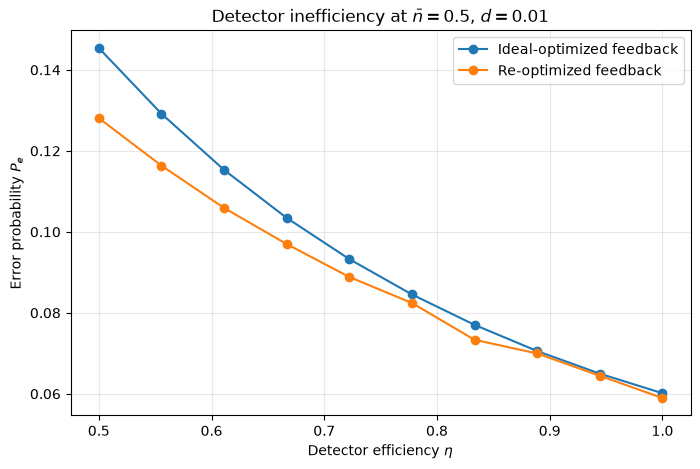

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    eta_values,
    ideal_strategy_errors,
    marker="o",
    label="Ideal-optimized feedback"
)

ax.plot(
    eta_values,
    reoptimized_errors,
    marker="o",
    label="Re-optimized feedback"
)

ax.set_xlabel(r"Detector efficiency $\eta$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title(
    rf"Detector inefficiency at $\bar{{n}}={nbar_test}$, $d={dark_count}$"
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

4